In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"


In [2]:
import sys
sys.path.append('../../utils/') 
from post_anal_plot import * 

### readin the prepared excel from previous steps

In [3]:
df_full = pd.read_excel("plot_rankshift_whdpLCI.xlsx")
#df_full_sorted.head()


### pairwise GAP plot 

#### function

In [4]:
### updated function with both GAP magnitude and direction

# ============================================================
# Global SSP display mapping (used in ALL plots)
# ============================================================
SSP_LABEL_MAP = {
    "SSP1-VLLO": "SSP1-19",
    "SSP2-M":    "SSP2-45",
    "SSP5-H":    "SSP5-85",
}

def format_ssp(ssp: str) -> str:
    """Return standardized display name for SSP."""
    return SSP_LABEL_MAP.get(ssp, ssp)



#### old plot 

#### updated plot, no size for marker, more grid 

In [5]:
def plot_pairwise_gaps_grid_directional(
    df_long,
    country,
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=None,
    metric_labels=None,
    pairs=None,
    figsize=(14, 10),
    directional=True,
    marker_size=120,   # fixed marker size (points^2)
    ylim_pad=6,        # % points padding around extrema
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    if metric_order is None:
        raise ValueError("metric_order must be provided.")
    if metric_labels is None:
        metric_labels = {m: m for m in metric_order}
    if pairs is None:
        raise ValueError("You must provide `pairs`, e.g. (('PV','Wind'), ('Hydro','PV'))")

    # ------------------------------------------------------------------
    # Styling from pairs (order-safe)
    # ------------------------------------------------------------------
    marker_cycle = ["o", "s", "D", "^", "v", "P", "X"]
    gray_cycle   = ["0.25", "0.45", "0.65", "0.35", "0.55", "0.75"]

    marker_map, gray_map = {}, {}
    for i, (a, b) in enumerate(pairs):
        label = f"{a} vs {b}"
        marker_map[label] = marker_cycle[i % len(marker_cycle)]
        gray_map[label]   = gray_cycle[i % len(gray_cycle)]

    # ------------------------------------------------------------------
    # Figure (NO sharey)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(years),
        figsize=figsize,
        sharey=False,
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.20)

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    for i, ssp in enumerate(ssps):
        for j, year in enumerate(years):

            ax = axes[i, j]

            sub = df_long[
                (df_long["Country"] == country) &
                (df_long["SSP"] == ssp) &
                (df_long["Year"] == year)
            ]

            if sub.empty:
                ax.set_axis_off()
                continue

            x = np.arange(len(metric_order))

            # collect panel gaps for dynamic y-limits
            panel_all_gaps = []

            for (a, b) in pairs:
                label = f"{a} vs {b}"
                gaps = []

                for m in metric_order:
                    sm = sub[sub["Metric"] == m].set_index("Technology")["Score"]

                    if a in sm.index and b in sm.index:
                        sa, sb = float(sm.loc[a]), float(sm.loc[b])
                        mag = abs(sa - sb) / max(sa, sb) * 100.0
                        gap = (+mag if sa < sb else -mag) if directional else mag
                        gaps.append(gap)
                    else:
                        gaps.append(np.nan)

                gaps = np.array(gaps, dtype=float)
                panel_all_gaps.append(gaps)

                ax.scatter(
                    x,
                    gaps,
                    s=marker_size,                 # fixed size
                    marker=marker_map[label],
                    facecolor=gray_map[label],
                    edgecolor="black",
                    linewidth=0.8,
                    alpha=0.9,
                    zorder=5,
                    label=label if (i == 0 and j == 0) else None,
                )

            # ------------------------------------------------------------------
            # Reference line (ONLY zero line; no 5% red lines)
            # ------------------------------------------------------------------
            ax.axhline(0, color="black", linewidth=0.9)

            # ------------------------------------------------------------------
            # Dynamic y-limits + adaptive grid spacing
            # ------------------------------------------------------------------
            panel_all_gaps = np.concatenate(panel_all_gaps) if len(panel_all_gaps) else np.array([])
            panel_all_gaps = panel_all_gaps[~np.isnan(panel_all_gaps)]

            if panel_all_gaps.size == 0:
                y_min, y_max = -10, 10
            else:
                y_min = float(np.min(panel_all_gaps)) - ylim_pad
                y_max = float(np.max(panel_all_gaps)) + ylim_pad

            # symmetric around 0 + round up to nearest 5
            m = max(abs(y_min), abs(y_max))
            m = float(np.ceil(m / 5.0) * 5.0)
            y_min, y_max = -m, m
            ax.set_ylim(y_min, y_max)

            # if abs(y-max) > 60 => 15% grid; else 10% grid
            step = 15 if m > 60 else 10
            yticks = np.arange(-m, m + 0.1, step)
            ax.set_yticks(yticks)
            ax.set_yticklabels([f"{int(v)}%" for v in yticks], fontsize=11)

            # grid styling to match barplot (dashed, darker)
            ax.grid(
                axis="y",
                linestyle="--",
                linewidth=0.9,
                alpha=0.8,
                color="0.35"
            )

            # ------------------------------------------------------------------
            # Titles & x labels
            # ------------------------------------------------------------------
            ax.set_title(f"{country}, {format_ssp(ssp)}, {year}", fontsize=12)
            ax.set_xticks(x)

            if i == len(ssps) - 1:
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=20,
                    ha="right",
                    fontsize=10,
                )
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(
                    "Directional pairwise gap (%)\n(+ = first tech lower GWP)",
                    fontsize=11,
                )

    # ------------------------------------------------------------------
    # Legend (dynamic, directional, marker-preserving)
    # ------------------------------------------------------------------
    legend_handles = []
    for (a, b) in pairs:
        label = f"{a} vs {b}"
        legend_label = (
            f"+ : {a} lower impact than {b} (by Δ %)\n"
            f"− : {a} higher impact than {b} (by Δ %)\n"
            f"Δ = |{a} − {b}| / max({a}, {b}) × 100"
        )
        handle = Line2D(
            [0], [0],
            marker=marker_map[label],
            linestyle="None",
            markerfacecolor=gray_map[label],
            markeredgecolor="black",
            markeredgewidth=0.8,
            markersize=9,
            label=legend_label,
        )
        legend_handles.append(handle)

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(pairs),
        fontsize=11,
        frameon=True,
        bbox_to_anchor=(0.5, -0.08),
    )

    fig.suptitle(
        "Pairwise technology gaps across metrics",
        fontsize=15,
        y=0.95,
    )

    return fig, axes

#### plot 

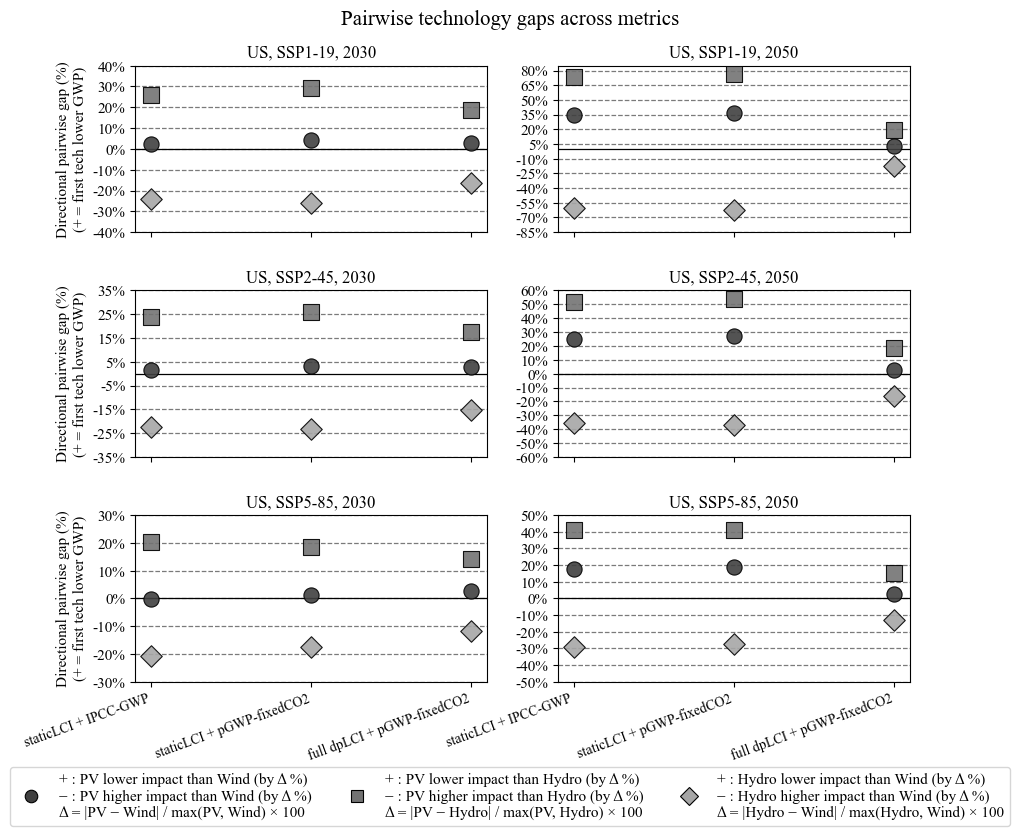

In [11]:
metric_order = [  #'dyn-FG-LCI + pGWP-fixedCO2', 
        
                  'staticLCI + IPCC-GWP', 
                  'staticLCI + pGWP-fixedCO2', 
                  #'staticLCI + pGWP-dpCO2', 
                  'full dpLCI + pGWP-fixedCO2',
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    #'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    #'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}


fig, axes = plot_pairwise_gaps_grid_directional(
    df_long=df_full,
    country="US",
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=metric_order,
    metric_labels=metric_labels,
    pairs=(("PV","Wind"), ( "PV", "Hydro"), ("Hydro", "Wind")),
    #directional  = TRUE 
    #gap_threshold_pct=5.0,  #only if we wanna add abline 
    figsize=(10, 8), #(12,9)
)

fig.savefig("fig_output/dot_pairwise_gap_US.png", dpi=600, bbox_inches="tight")

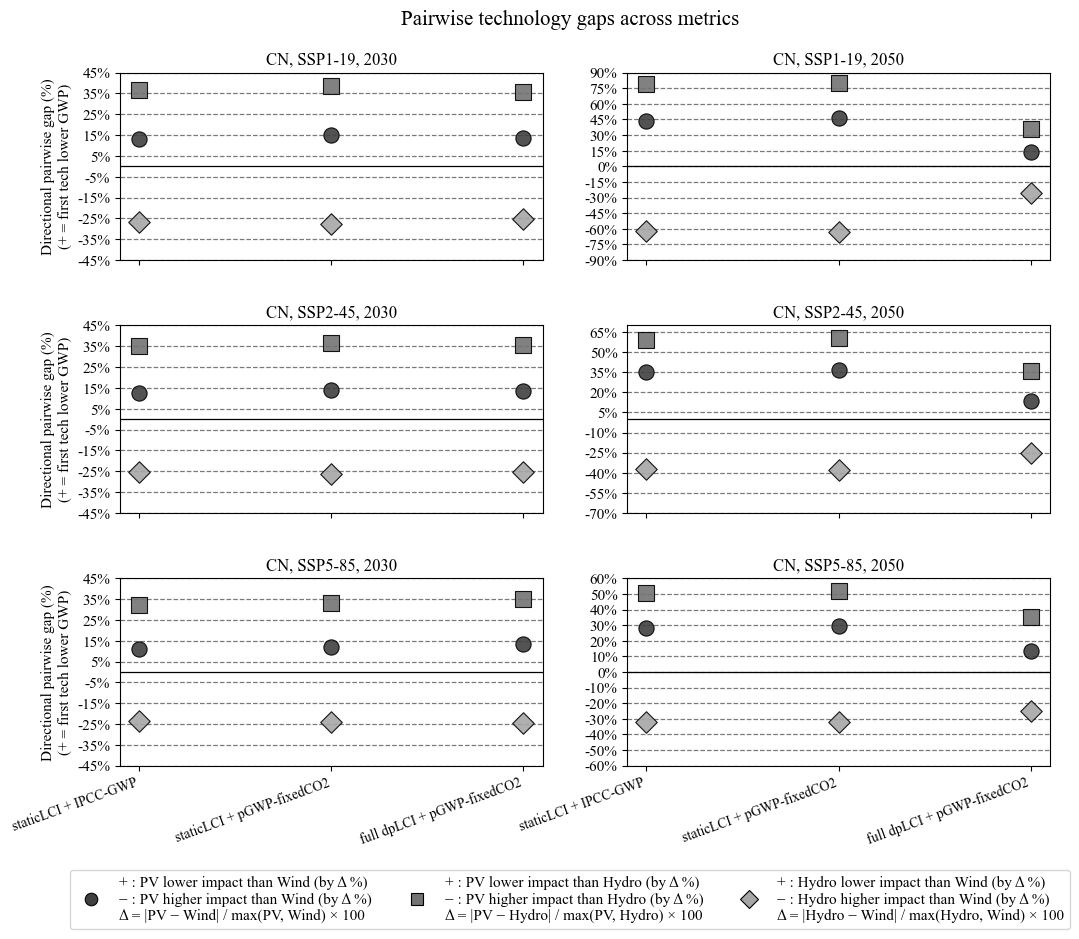

In [9]:
fig, axes = plot_pairwise_gaps_grid_directional(
    df_long=df_full,
    country="CN",
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    years=(2030, 2050),
    metric_order=metric_order,
    metric_labels=metric_labels,
    pairs=(("PV","Wind"), ( "PV", "Hydro"), ("Hydro", "Wind")),
    #directional  = TRUE 
    #gap_threshold_pct=5.0,  #only if we wanna add abline 
    figsize=(12, 9),
)

fig.savefig("fig_output/dot_pairwise_gap_CN.png", dpi=600, bbox_inches="tight")